In [190]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
from _notebook_init import DATA_PROCESSED

from weather_markov.models.nonuniform_Markov_chain import NonUniformMarkovChainPredictor
from weather_markov.preprocessing.discretizer import TemperatureDiscretizer
from weather_markov.visualization.plots import (
    plot_graph_network,
    plot_prediction_distribution,
    plot_transition_matrix,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### test on previous years

In [191]:
decade_df = pd.read_csv(DATA_PROCESSED / "decades.csv")

disc = TemperatureDiscretizer.from_equal_width(n_bins=14, t_min=-15, t_max=20)

train_years = range(2015, 2026)
test_years = range(2015, 2026)

train_df = decade_df[decade_df["year"].isin(train_years)]
test_df = decade_df[decade_df["year"].isin(test_years)]

disc.fit(train_df["avg_temperature"])
model = NonUniformMarkovChainPredictor(disc).fit(train_df)

len(model.transition_matrices), model.transition_labels[0], model.transition_labels[-1]

(9, ((2, 1), (2, 2)), ((4, 3), (5, 1)))

In [192]:
for label, matrix in zip(model.transition_labels, model.transition_matrices):
    print(f"{label[0]} -> {label[1]}: {matrix.shape}")
    # direct heatmap via existing helper expects TransitionGraph; use pandas plot below if needed

(2, 1) -> (2, 2): (14, 14)
(2, 2) -> (2, 3): (14, 14)
(2, 3) -> (3, 1): (14, 14)
(3, 1) -> (3, 2): (14, 14)
(3, 2) -> (3, 3): (14, 14)
(3, 3) -> (4, 1): (14, 14)
(4, 1) -> (4, 2): (14, 14)
(4, 2) -> (4, 3): (14, 14)
(4, 3) -> (5, 1): (14, 14)


                (-15.0, -12.5]  (-12.5, -10.0]  (-10.0, -7.5]  (-7.5, -5.0]  \
(-15.0, -12.5]        0.071429        0.071429       0.071429      0.071429   
(-12.5, -10.0]        0.000000        0.000000       0.000000      0.000000   
(-10.0, -7.5]         0.500000        0.000000       0.000000      0.500000   
(-7.5, -5.0]          0.000000        0.000000       0.000000      1.000000   
(-5.0, -2.5]          0.000000        0.000000       0.000000      0.000000   
(-2.5, 0.0]           0.000000        0.000000       0.333333      0.000000   
(0.0, 2.5]            0.000000        0.000000       0.000000      0.000000   
(2.5, 5.0]            0.071429        0.071429       0.071429      0.071429   
(5.0, 7.5]            0.071429        0.071429       0.071429      0.071429   
(7.5, 10.0]           0.071429        0.071429       0.071429      0.071429   
(10.0, 12.5]          0.071429        0.071429       0.071429      0.071429   
(12.5, 15.0]          0.071429        0.071429      

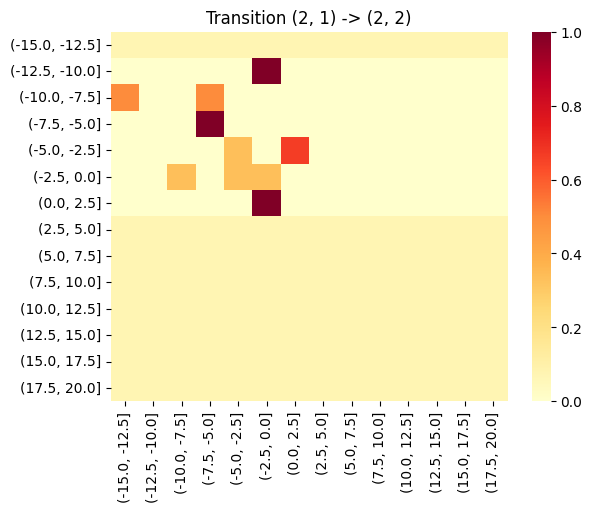

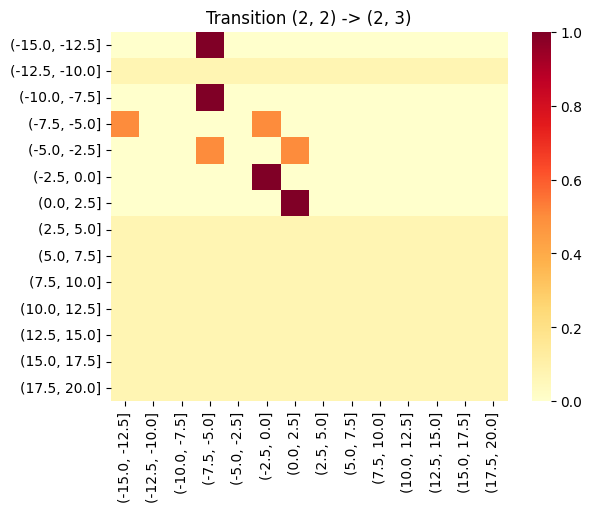

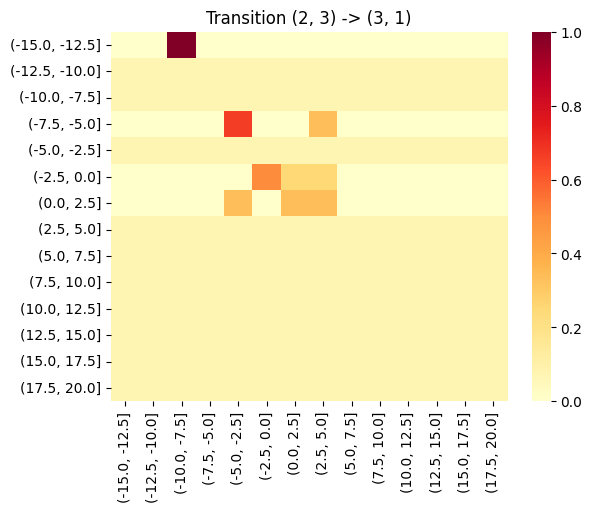

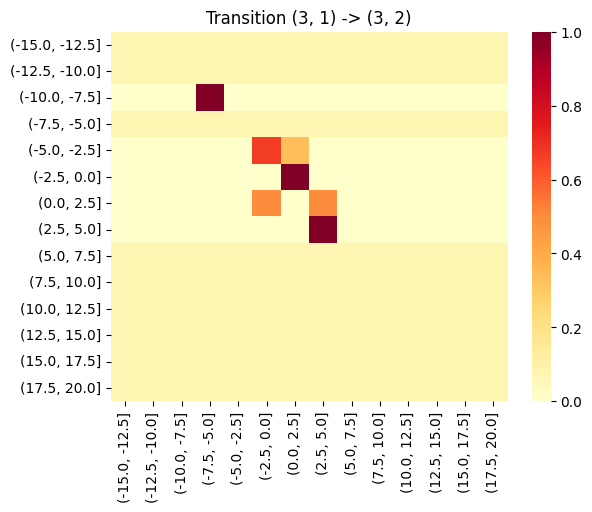

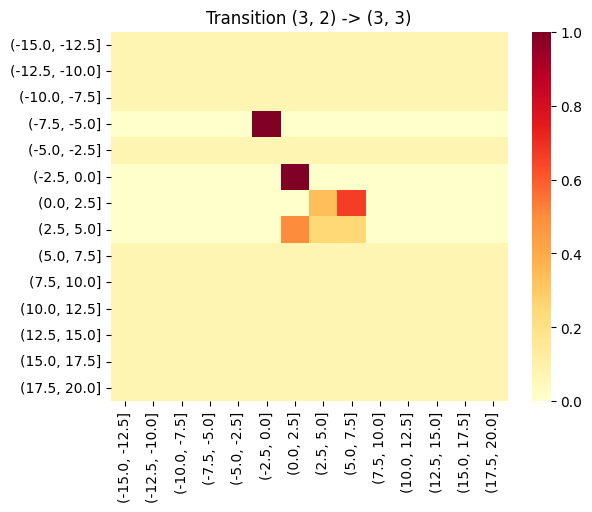

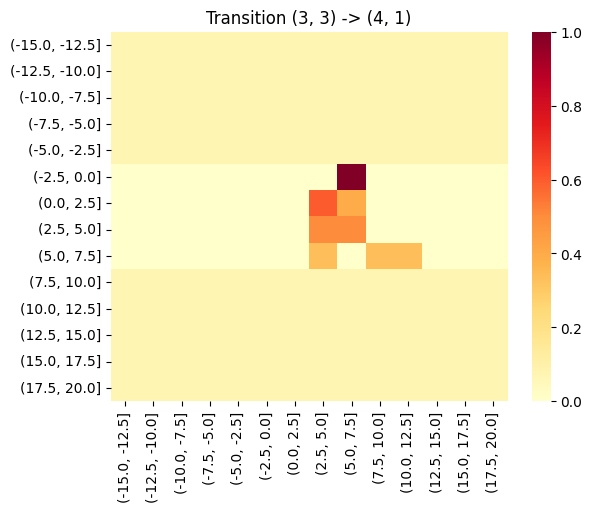

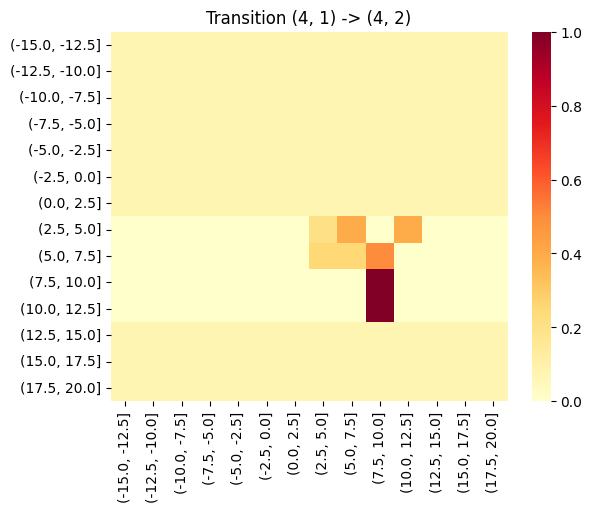

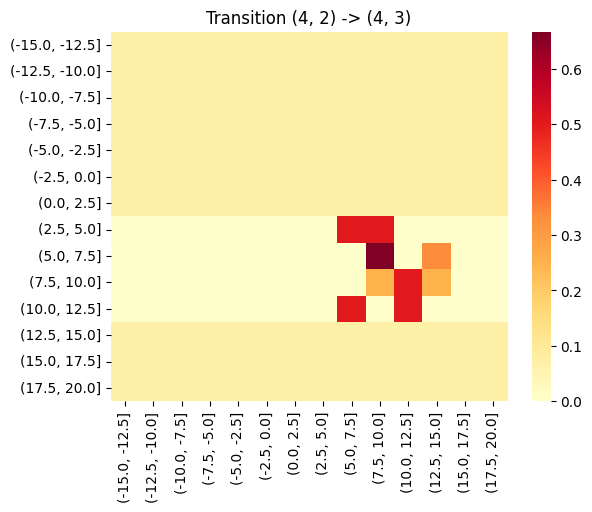

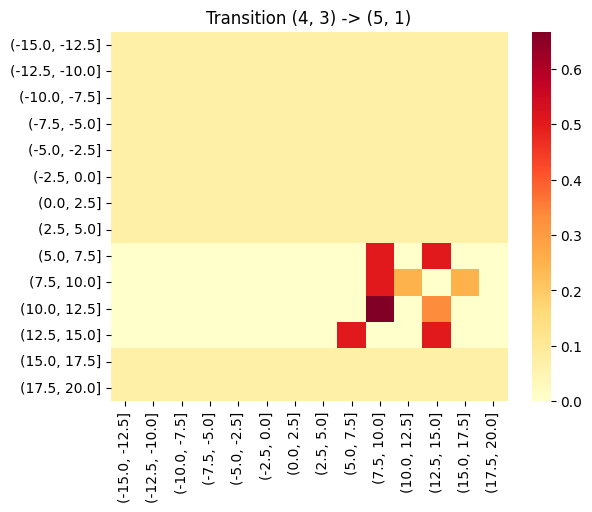

In [193]:
# Optional: visualize first and last step matrices as heatmaps
import seaborn as sns
import matplotlib.pyplot as plt

print(model.transition_matrices[0])

for i in range(len(model.transition_labels)):
    label = model.transition_labels[i]
    matrix = model.transition_matrices[i]
    sns.heatmap(matrix, annot=False, cmap="YlOrRd")
    plt.title(f"Transition {label[0]} -> {label[1]}")
    plt.show()

In [194]:
results = []

for test_year in test_years:
    feb_first_decade_temp = test_df[
        (test_df["year"] == test_year)
        & (test_df["month"] == 2)
        & (test_df["decade"] == 1)
    ]["avg_temperature"].iloc[0]

    may_first_decade_temp = test_df[
        (test_df["year"] == test_year)
        & (test_df["month"] == 5)
        & (test_df["decade"] == 1)
    ]["avg_temperature"].iloc[0]

    start_state = disc.transform(pd.Series([feb_first_decade_temp])).iloc[0]
    pred_dist = model.predict(start_state)
    pred_label = model.predict_label(start_state)
    true_label = disc.transform(pd.Series([may_first_decade_temp])).iloc[0]

    results.append(
        {
            "year": test_year,
            "pred": pred_label,
            "true": true_label,
            "feb_temp": feb_first_decade_temp,
            "correct": pred_label == true_label,
            "dist": pred_dist,
        }
    )

In [195]:
results_df = pd.DataFrame(results)
results_df

,year,pred,true,feb_temp,correct,dist
0,2015,"(7.5, 10.0]","(10.0, 12.5]",-4.425417,False,"{'(-15.0, -12.5]': 0.0, '(-12.5, -10.0]': 0.0,..."
1,2016,"(7.5, 10.0]","(12.5, 15.0]",0.147500,False,"{'(-15.0, -12.5]': 0.0, '(-12.5, -10.0]': 0.0,..."
2,2017,"(7.5, 10.0]","(7.5, 10.0]",-10.198750,True,"{'(-15.0, -12.5]': 0.0, '(-12.5, -10.0]': 0.0,..."
3,2018,"(7.5, 10.0]","(15.0, 17.5]",-7.908750,False,"{'(-15.0, -12.5]': 0.0, '(-12.5, -10.0]': 0.0,..."
4,2019,"(7.5, 10.0]","(12.5, 15.0]",-1.571250,False,"{'(-15.0, -12.5]': 0.0, '(-12.5, -10.0]': 0.0,..."
5,2020,"(7.5, 10.0]","(12.5, 15.0]",-3.285000,False,"{'(-15.0, -12.5]': 0.0, '(-12.5, -10.0]': 0.0,..."
6,2021,"(7.5, 10.0]","(7.5, 10.0]",-9.970000,True,"{'(-15.0, -12.5]': 0.0, '(-12.5, -10.0]': 0.0,..."
7,2022,"(7.5, 10.0]","(7.5, 10.0]",-3.138750,True,"{'(-15.0, -12.5]': 0.0, '(-12.5, -10.0]': 0.0,..."
8,2023,"(7.5, 10.0]","(7.5, 10.0]",-2.007500,True,"{'(-15.0, -12.5]': 0.0, '(-12.5, -10.0]': 0.0,..."
9,2024,"(7.5, 10.0]","(5.0, 7.5]",-5.097500,False,"{'(-15.0, -12.5]': 0.0, '(-12.5, -10.0]': 0.0,..."


### 2026 prediction

In [196]:
disc = TemperatureDiscretizer.from_equal_width(n_bins=14, t_min=-15, t_max=20)

train_years = range(2015, 2026)

train_df = decade_df[decade_df["year"].isin(train_years)]

disc.fit(train_df["avg_temperature"])
model = NonUniformMarkovChainPredictor(disc).fit(train_df)

In [197]:
current_year = 2026

feb_first_decade_temp = decade_df[
    (decade_df["year"] == current_year)
    & (decade_df["month"] == 2)
    & (decade_df["decade"] == 1)
]["avg_temperature"].iloc[0]

start_state = disc.transform(pd.Series([feb_first_decade_temp])).iloc[0]
pred_dist = model.predict(start_state)
pred_label = model.predict_label(start_state)

pred_label

'(7.5, 10.0]'

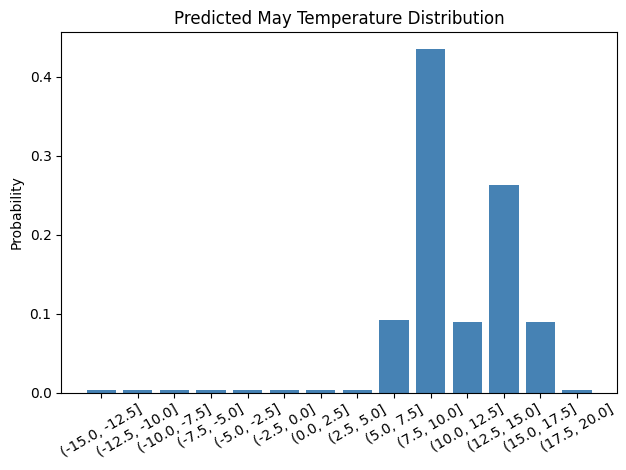

In [198]:
plot_prediction_distribution(pred_dist)